In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0. Cargar Datos

In [39]:
path_ventas = "datos/Ventas por Cliente/ventas_con_precio_lista_y_descuentos_2025_2026.csv"
ventas = pd.read_csv(path_ventas)
ventas.head()

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_36362/598381596.py:2: DtypeWarning: Columns (0: dscto_volumen, 1: ids_descuento_volumen) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Distrito,Precio_Lista,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,PUNTA ARENAS,11538.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,HR,ZV01,2025-01-03,43790,NaN,55,HORECA VOLUMEN,MORTADELAS,...,SANTIAGO HORECA PAP,2715.0,-3.0,2352.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,HR,ZV01,2025-01-03,1227049,NaN,37,OTROS HORECA,VIENESAS,...,SANTIAGO HORECA PAP,2722.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,CB,ZV01,2025-01-02,1174760,NaN,32,COBERTURA,HAMBURGUESAS,...,NaN,5171.0,-12.5,2372.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,HR,ZV01,2025-01-03,1015869,NaN,55,HORECA VOLUMEN,PARRILLEROS,...,SANTIAGO HORECA PAP,3232.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
ventas.columns

Index(['Año', 'Mes', 'Cod Canal Comercial', 'Clase Factura', 'Fecha Factura',
       'Cod Cliente', 'Nombre Cliente Padre', 'Cod Consolidado',
       'Nombre Consolidado', 'Nombre Familia', 'N° Factura', 'Nombre Marca',
       'Nombre Tipo Carne', 'Cod SKU', 'Nombre SKU', 'Factura Venta',
       'Factura Kilos', 'Kilo Real', 'Kilos Nc', 'Monto Nc', 'Monto Real',
       'Precio', 'venta_id', 'Zona', 'Distrito', 'Precio_Lista', 'dscto_base',
       'id_descuento_base', 'dscto_volumen', 'ids_descuento_volumen',
       'dscto_binario', 'id_descuento_binario', 'carta_impacto',
       'id_descuento_carta_impacto'],
      dtype='str')

In [41]:
# Filtrar solo los canales relevantes
canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
    "MAYORISTAS CADENAS",
    "MAYORISTA B VOLUMEN",
    "OTROS MAYORISTAS",
    "HORECA VOLUMEN",
    "OTROS HORECA",
]
ventas = ventas[ventas["Nombre Consolidado"].isin(canales_relevantes)]
print("Ventas después de filtrar canales irrelevantes - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar canales irrelevantes - Filas: 10364933


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Distrito,Precio_Lista,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,PUNTA ARENAS,11538.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,HR,ZV01,2025-01-03,43790,NaN,55,HORECA VOLUMEN,MORTADELAS,...,SANTIAGO HORECA PAP,2715.0,-3.0,2352.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,HR,ZV01,2025-01-03,1227049,NaN,37,OTROS HORECA,VIENESAS,...,SANTIAGO HORECA PAP,2722.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,CB,ZV01,2025-01-02,1174760,NaN,32,COBERTURA,HAMBURGUESAS,...,NaN,5171.0,-12.5,2372.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,HR,ZV01,2025-01-03,1015869,NaN,55,HORECA VOLUMEN,PARRILLEROS,...,SANTIAGO HORECA PAP,3232.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
cols = [
    "Fecha Factura",
    "Cod SKU",
    "Nombre SKU",
    'Nombre Marca',
    'Nombre Familia',
    "Kilo Real",
    "Monto Real",
    "Precio"
]
# Botar filas con nans en las columnas relevantes
ventas = ventas.dropna(subset=cols)
print("Ventas después de filtrar nans - Filas:", ventas.shape[0])
ventas = ventas[cols]

Ventas después de filtrar nans - Filas: 10364927


In [43]:
# Cargar datos
path_maestro = "datos/Maestro Productos.xlsx"
maestro = pd.read_excel(path_maestro, header=2)
maestro.head()

,Material,Texto breve de material,Material - COD SKU,Grupo art.,Creado el,Estado,Válido de,GTPos,Denominación,Bruto,...,Denominación.1,Tip Carne,Denom..1,Gr. Empaq.,Denom..2,Gr. Carga,Denominación.2,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,ARROLLADO LOMO CON AJI SJ,20,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.170,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,ARROLLADO LOMO CORTADO SJ,21,SJ,20.10.2005,BLOQUEADO,19.10.2020,NORM,Posición normal,2.030,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,25,SJ,27.01.2011,BLOQUEADO,08.04.2016,NORM,Posición normal,0.253,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,26,SJ,23.05.2013,BLOQUEADO,18.03.2020,NORM,Posición normal,0.256,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,ARROLLADO LOMO SIN AJI SJ,27,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.389,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [44]:
# Filtrar columnas relevantes
cols_relevantes_maestro = [
    # Id Producto
    "Material",
    # Info Producto
    "Texto breve de material",
    # Producto con peso cte?
    "Peso Var/Std",
    # Kg por Unidad
    "Neto"
]
maestro = maestro[cols_relevantes_maestro]
maestro["peso_variable"] = maestro["Peso Var/Std"] != "Peso Standard"
maestro.drop(columns="Peso Var/Std", inplace=True)
maestro.head()

,Material,Texto breve de material,Neto,peso_variable
0,20,ARROLLADO LOMO CON AJI SJ,3.172,True
1,21,ARROLLADO LOMO CORTADO SJ,2.000,False
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,0.250,False
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,0.250,False
4,27,ARROLLADO LOMO SIN AJI SJ,3.268,True


# 1. Cruzar bases

In [45]:
ventas.columns = [
    "fecha_factura",
    "cod_sku",
    "nombre_sku",
    "nombre_marca",
    "nombre_familia",
    "kilo_real",
    "monto_real",
    "precio_real",
]
ventas["fecha_factura"] = pd.to_datetime(ventas["fecha_factura"], errors="coerce")
ventas = ventas.dropna(subset=["fecha_factura"]).copy()
ventas["año_factura"] = ventas["fecha_factura"].dt.year.astype(int)
ventas["mes_factura"] = ventas["fecha_factura"].dt.month.astype(int)

maestro.columns = [
    "cod_sku",
    "texto_breve_material",
    "kg_por_unidad",
    "peso_variable"
]
# Agregar columna de kg_por_unidad a ventas
ventas = ventas.merge(maestro[["cod_sku", "kg_por_unidad", "peso_variable"]], on="cod_sku", how="left")

# Calcular cantidad en unidades
ventas["cantidad_unidades"] = ventas["kilo_real"] / ventas["kg_por_unidad"]
ventas.head()
# Revisar que columnas con cantidad_unidades no entera sean las mismas que las que tienen peso_variable = True
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades"].isna() | np.isclose(ventas["cantidad_unidades"], np.round(ventas["cantidad_unidades"]), atol=1e-6, rtol=0)

ventas["peso_variable"] = ventas["peso_variable"].fillna(False)
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades_entera"].fillna(True)
ventas["inconsistencia"] = (ventas["peso_variable"] == False) & (ventas["cantidad_unidades_entera"] == False)

ventas["inconsistencia"].value_counts()
# Ver columnas con inconsistencia
ventas[ventas["inconsistencia"]].head()
# Decidir que hacer con estas filas
# -> Redondear unidades a entero, dejar registro en un columna unidades_redondeadas (Bool)
ventas["cantidad_unidades"] = np.where(ventas["inconsistencia"], np.round(ventas["cantidad_unidades"]), ventas["cantidad_unidades"])
ventas = ventas[ventas["cantidad_unidades"] > 0]
ventas["precio_por_unidad"] = ventas["monto_real"] / ventas["cantidad_unidades"]
ventas.head()

,fecha_factura,cod_sku,nombre_sku,nombre_marca,nombre_familia,kilo_real,monto_real,precio_real,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,precio_por_unidad
0,2025-01-02,3034,SALAME 10x100 GR LP,LA PREFERIDA,SALAMES,4.0,43440,10860.000000,2025,1,0.10,False,40.0,True,False,1086.000000
1,2025-01-03,399,MORTADELA LISA 3 KG SJ,SAN JORGE,MORTADELAS,12.0,31608,2634.000000,2025,1,3.00,False,4.0,True,False,7902.000000
2,2025-01-03,1006,VIENESA 10X380 GR SJ,SAN JORGE,VIENESAS,30.4,82749,2722.006579,2025,1,0.38,False,80.0,True,False,1034.362500
3,2025-01-02,3991,HAMBURGUESA GRILL TASTE LP 24x100 GR.,LA PREFERIDA,HAMBURGUESAS,2.4,10862,4525.833333,2025,1,0.10,False,24.0,True,False,452.583333
4,2025-01-03,1446,LONGANIZA SJ 800 GR.,SAN JORGE,PARRILLEROS,4.8,15048,3135.000000,2025,1,0.80,False,6.0,True,False,2508.000000


# 2. Análisis

In [46]:
# Filtrar solo segundo semestre 2025
ventas = ventas[ventas["año_factura"] == 2025]
ventas = ventas[ventas["mes_factura"] >= 7]
print("Ventas después de filtrar por fecha - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar por fecha - Filas: 4107693


,fecha_factura,cod_sku,nombre_sku,nombre_marca,nombre_familia,kilo_real,monto_real,precio_real,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,precio_por_unidad
93,2025-09-16,738,"SALCHICHON CERVEZA 1,6 KG SJ",SAN JORGE,MORTADELAS,1.6,3206,2003.750000,2025,9,1.6,False,1.0,True,False,3206.0
94,2025-09-03,3922,QUESO CABEZA LP,LA PREFERIDA,TIPICOS,3.0,15513,5171.000000,2025,9,3.0,False,1.0,True,False,15513.0
95,2025-08-18,3922,QUESO CABEZA LP,LA PREFERIDA,TIPICOS,3.0,15048,5016.000000,2025,8,3.0,False,1.0,True,False,15048.0
99,2025-08-15,3922,QUESO CABEZA LP,LA PREFERIDA,TIPICOS,3.0,15514,5171.333333,2025,8,3.0,False,1.0,True,False,15514.0
100,2025-07-14,3908,PECHUGA DE POLLO ACARAMELADO LP,LA PREFERIDA,JAMON G2,45.0,361170,8026.000000,2025,7,2.5,True,18.0,True,False,20065.0


In [47]:
# Calculamos precio promedio por SKU
precio_promedio_sku = ventas.groupby(["cod_sku", "nombre_sku",
    'nombre_marca',
    'nombre_familia'])["precio_real"].mean().reset_index()

precio_promedio_sku.head()

,cod_sku,nombre_sku,nombre_marca,nombre_familia,precio_real
0,20,ARROLLADO LOMO CON AJI SJ,SAN JORGE,ARROLLADOS,4875.619929
1,27,ARROLLADO LOMO SIN AJI SJ,SAN JORGE,ARROLLADOS,4850.743935
2,30,ARROLLADO HUASO CON AJI SJ,SAN JORGE,ARROLLADOS,4876.242751
3,102,ARROLLADO LOMO CON AJI 12x150 GR SJ,SAN JORGE,ARROLLADOS,5599.548010
4,151,CHORIZO 12X250 GR SJ,SAN JORGE,PARRILLEROS,3555.047921


In [48]:
precio_promedio_sku["nombre_marca"].value_counts()

nombre_marca
LA PREFERIDA    107
SAN JORGE        79
WINTER           29
Los Nogales      12
QUILLAYES         2
LIDER             1
QUALY             1
SADIA             1
MAESTRO           1
Name: count, dtype: int64

In [49]:
precio_promedio_sku = precio_promedio_sku[~precio_promedio_sku["nombre_familia"].isin(["SNACKS", "SECOS"])]
precio_promedio_sku = precio_promedio_sku[precio_promedio_sku["nombre_marca"].isin(["SAN JORGE", "LA PREFERIDA", "WINTER", "Los Nogales"])]

In [50]:
precio_promedio_sku.to_excel("precios_promedio_por_sku.xlsx")

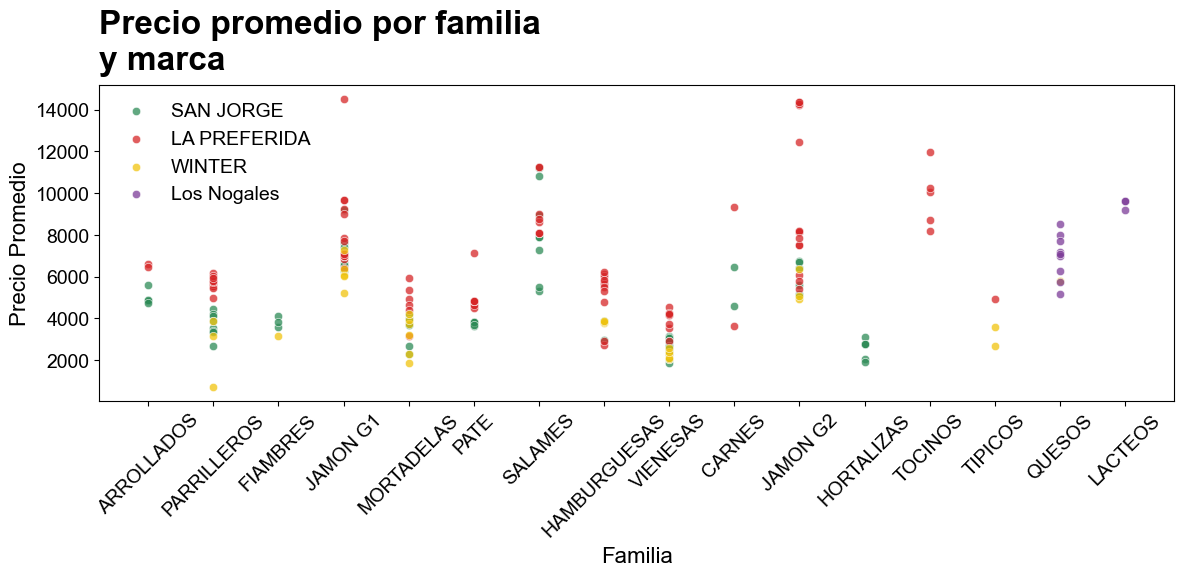

In [51]:
# Graficar un punto por SKU, agrupando en el eje X categorías por familia,
# en el eje Y el precio promedio y usando colores fijos por marca.

plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
})

colores_marcas = {
    'SAN JORGE': '#2E8B57',
    'LA PREFERIDA': '#D62728',
    'WINTER': '#F1C40F',
    'Los Nogales': '#7D3C98',
}

fig, ax = plt.subplots(figsize=(12, 6))
for marca, color in colores_marcas.items():
    subset = precio_promedio_sku[precio_promedio_sku['nombre_marca'] == marca]
    if subset.empty:
        continue
    ax.scatter(
        subset['nombre_familia'],
        subset['precio_real'],
        label=marca,
        color=color,
        alpha=0.75,
        edgecolors='white',
        linewidth=0.5,
    )

ax.set_xlabel('Familia')
ax.set_ylabel('Precio Promedio')
ax.text(
    0,
    1.05,
    'Precio promedio por familia\ny marca',
    transform=ax.transAxes,
    fontsize=24,
    fontweight='bold',
)
ax.tick_params(axis='x', rotation=45)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [52]:
precio_promedio_sku = precio_promedio_sku[precio_promedio_sku["nombre_marca"].isin(["SAN JORGE", "WINTER"])]

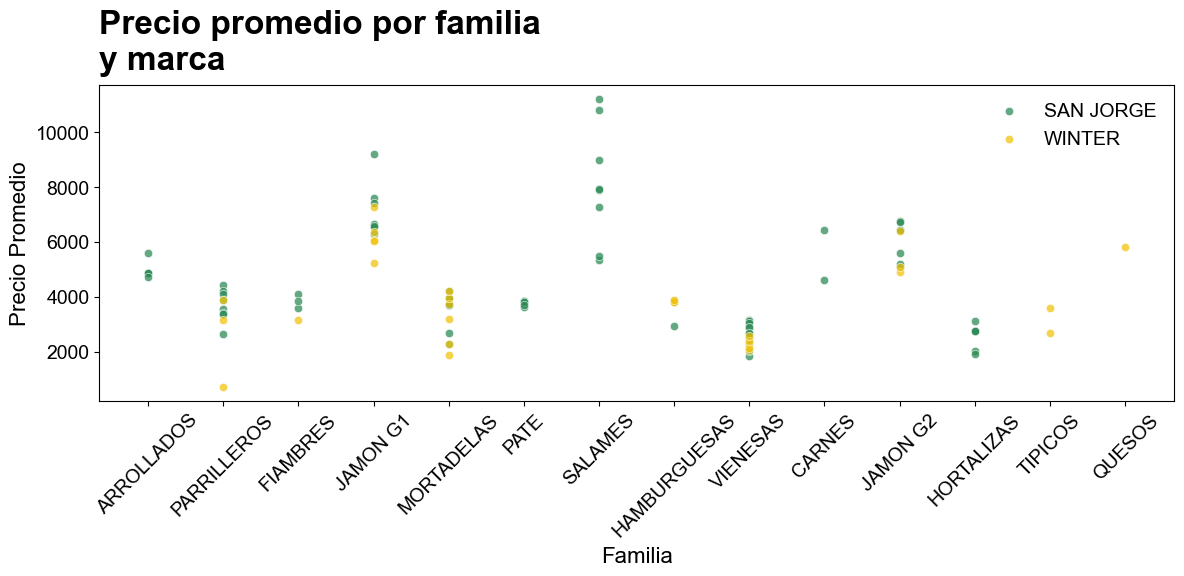

In [53]:
# Graficar un punto por SKU, agrupando en el eje X categorías por familia,
# en el eje Y el precio promedio y usando colores fijos por marca.

plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
})

colores_marcas = {
    'SAN JORGE': '#2E8B57',
    'LA PREFERIDA': '#D62728',
    'WINTER': '#F1C40F',
    'Los Nogales': '#7D3C98',
}

fig, ax = plt.subplots(figsize=(12, 6))
for marca, color in colores_marcas.items():
    subset = precio_promedio_sku[precio_promedio_sku['nombre_marca'] == marca]
    if subset.empty:
        continue
    ax.scatter(
        subset['nombre_familia'],
        subset['precio_real'],
        label=marca,
        color=color,
        alpha=0.75,
        edgecolors='white',
        linewidth=0.5,
    )

ax.set_xlabel('Familia')
ax.set_ylabel('Precio Promedio')
ax.text(
    0,
    1.05,
    'Precio promedio por familia\ny marca',
    transform=ax.transAxes,
    fontsize=24,
    fontweight='bold',
)
ax.tick_params(axis='x', rotation=45)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [54]:
precio_promedio_sku = precio_promedio_sku[precio_promedio_sku["nombre_familia"].isin(["VIENESAS", "MORTADELAS"])]

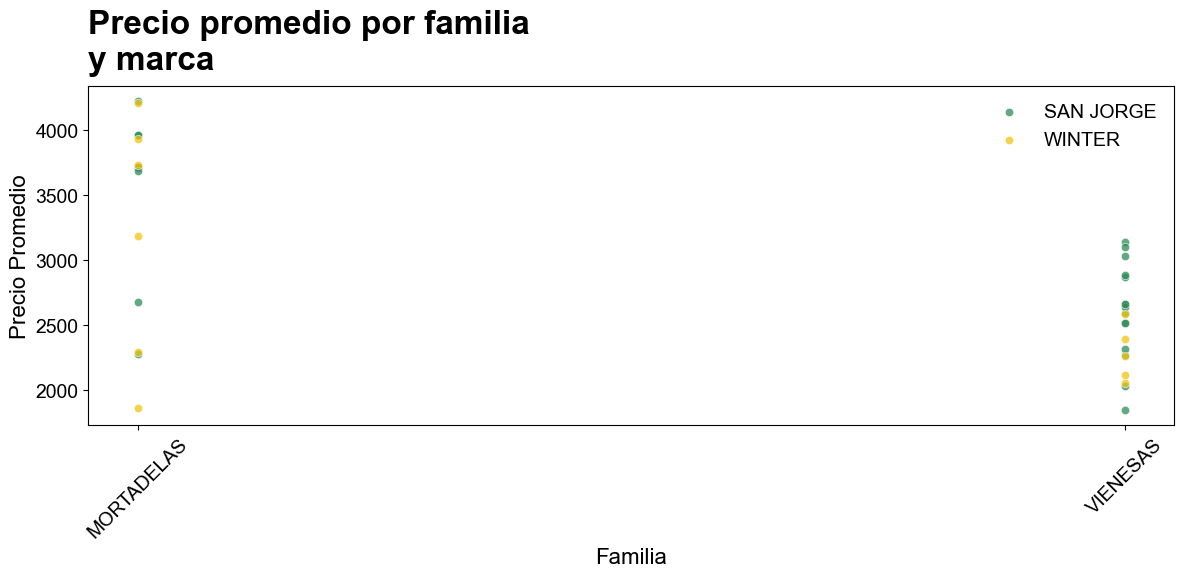

In [55]:
# Graficar un punto por SKU, agrupando en el eje X categorías por familia,
# en el eje Y el precio promedio y usando colores fijos por marca.

plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
})

colores_marcas = {
    'SAN JORGE': '#2E8B57',
    'LA PREFERIDA': '#D62728',
    'WINTER': '#F1C40F',
    'Los Nogales': '#7D3C98',
}

fig, ax = plt.subplots(figsize=(12, 6))
for marca, color in colores_marcas.items():
    subset = precio_promedio_sku[precio_promedio_sku['nombre_marca'] == marca]
    if subset.empty:
        continue
    ax.scatter(
        subset['nombre_familia'],
        subset['precio_real'],
        label=marca,
        color=color,
        alpha=0.75,
        edgecolors='white',
        linewidth=0.5,
    )

ax.set_xlabel('Familia')
ax.set_ylabel('Precio Promedio')
ax.text(
    0,
    1.05,
    'Precio promedio por familia\ny marca',
    transform=ax.transAxes,
    fontsize=24,
    fontweight='bold',
)
ax.tick_params(axis='x', rotation=45)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()